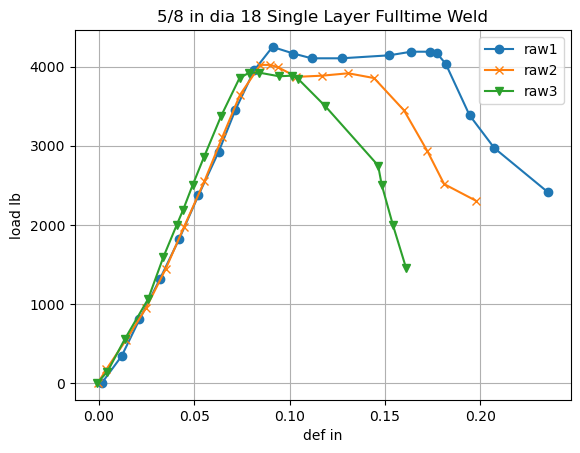

In [66]:
import math as m
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw1 = np.array([
    [0.001597444089456869, 469.69696969697],
    [0.011980830670926514, 810.606060606061],
    [0.021299254526091584, 1272.727272727273],
    [0.03194888178913737, 1780.30303030303],
    [0.04206602768903089, 2287.8787878787875],
    [0.05218317358892439, 2840.909090909091],
    [0.06283280085197018, 3393.939393939394],
    [0.07161874334398294, 3924.242424242424],
    [0.08146964856230032, 4424.242424242424],
    [0.09105431309904152, 4719.696969696969],
    [0.10197018104366345, 4636.363636363636],
    [0.11155484558040468, 4575.757575757575],
    [0.12726304579339723, 4575.757575757575],
    [0.15228966986155484, 4613.636363636363],
    [0.16373801916932904, 4659.090909090908],
    [0.17385516506922258, 4659.090909090908],
    [0.1770500532481363, 4643.939393939393],
    [0.18184238551650692, 4507.575757575757],
    [0.1943556975505857, 3856.0606060606056],
    [0.20740149094781682, 3439.393939393939],
    [0.2356230031948882, 2878.7878787878785]
])

raw2 = np.array([
    [-0.0005324813631522873, 553.0303030303039],
    [0.003993610223642169, 727.2727272727279],
    [0.014110756123535677, 1090.909090909091],
    [0.024760383386581465, 1500.0],
    [0.03514376996805111, 2000.0],
    [0.04472843450479232, 2530.3030303030305],
    [0.05537806176783811, 3106.060606060606],
    [0.0646964856230032, 3659.090909090909],
    [0.07401490947816824, 4196.969696969696],
    [0.08466453674121405, 4575.757575757575],
    [0.08998935037273695, 4575.757575757575],
    [0.09398296059637912, 4545.454545454545],
    [0.10356762513312034, 4424.242424242424],
    [0.11714589989350371, 4439.393939393939],
    [0.1307241746538871, 4469.696969696969],
    [0.14430244941427048, 4409.090909090909],
    [0.16001064962726302, 3999.9999999999995],
    [0.17225772097976572, 3484.848484848485],
    [0.18104366347177847, 3068.181818181818],
    [0.1978168264110756, 2856.060606060606]
])

raw3 = np.array([
    [-0.0007987220447284379, 500.0],
    [0.004526091586794463, 643.939393939394],
    [0.013578274760383376, 1053.030303030303],
    [0.02582534611288604, 1560.6060606060605],
    [0.03381256656017039, 2090.909090909091],
    [0.040734824281150155, 2492.424242424242],
    [0.04419595314164002, 2689.3939393939395],
    [0.049254526091586794, 3007.5757575757575],
    [0.05511182108626198, 3356.060606060606],
    [0.06416400425985089, 3878.7878787878785],
    [0.07374866879659212, 4356.060606060606],
    [0.07880724174653886, 4424.242424242424],
    [0.08413205537806176, 4424.242424242424],
    [0.0945154419595314, 4378.787878787878],
    [0.10117145899893504, 4386.363636363636],
    [0.10436634717784876, 4348.484848484848],
    [0.1187433439829606, 4000.0],
    [0.14643237486687966, 3250.0],
    [0.14829605963791265, 3007.5757575757575],
    [0.15415335463258784, 2500.0],
    [0.1610756123535676, 1954.5454545454545]
])


x1= raw1[:,0]
y1 = raw1[:,1]-469.69696969697
x2= raw2[:,0]
y2 = raw2[:,1]-553.0303030303039
x3= raw3[:,0]
y3 = raw3[:,1]-500.0
plt.figure()
plt.plot(x1,y1,marker='o',label="raw1")
plt.plot(x2,y2,marker='x',label="raw2")
plt.plot(x3,y3,marker='v',label="raw3")
plt.ylabel('load lb')
plt.xlabel('def in')
plt.title("5/8 in dia 18 Single Layer Fulltime Weld")
plt.grid(True)
plt.legend()
plt.show()

In [68]:
def support_group(n_col, n_row, col_spacing, row_spacing):
    x_support = []
    y_support = []
    for i in range(n_col):
        for j in range(n_row):
            x_support.append(i * col_spacing - (n_col - 1) * col_spacing / 2)
            y_support.append(j * row_spacing - (n_row - 1) * row_spacing / 2)
    return x_support, y_support

In [70]:
def force_from_curve(delta_i, delta_tab,force_tab, normalize_by = None):
    # castining deformations and force values into numpy arrays b/c NumPy arrays let us do fast, vectorized math
    delta_tab = np.asarray(delta_tab,dtype=float) 
    force_tab = np.asarray(force_tab,dtype=float)
    x = np.asarray(delta_tab, float)
    y = np.asarray(force_tab, float)

    #cliping delta values to the range using clipping If value < min_val, it gets replaced by min_val. Same is true the other way
    xi = np.clip(np.asarray(delta_i, float), x.min(), x.max()) #so if delta_i is < minimum deformation it is xmin (same for xmax), this is b/c We don’t want to interpolate outside the tabulated data range. 
    f = np.interp(xi, x, y)              # capped interpolation
    f = np.clip(f, 0.0, y.max())         # guard against tiny numeric overshoots, f < 0.0 → set it to 0., If f > y.max() → set it to y.max().
    if normalize_by is not None:
        f = np.clip(f / float(normalize_by), 0.0, 1.0) # we are making sure Makes sure normalized FORCE results are always between 0 and 1. We use this
        # if we normalize by pf_arc
    return f

In [80]:
def ICM1(x_load, y_load, x_coord, y_coord, fastener_types, ArcDataLabel, screw_params,delta_max,lamda):
    x_centroid, y_centroid = np.mean(x_coord), np.mean(y_coord)
    n = len(x_coord)

    
    raw = curves[ArcDataLabel]
    delta_tab = raw[:, 0]
    force_tab = raw[:, 1] / 1000
    P_f_arc = max(raw[:, 1]) / 1000  # corrected (was raw1)
    

    Ke, Ks, Kc, Kr = screw_params['Ke'], screw_params['Ks'], screw_params['Kc'], screw_params['Kr']
    dy, dc, dr, df_screw = screw_params['dy'], screw_params['dc'], screw_params['dr'], screw_params['df']
    Fc = screw_params['Fc']  # peak force for normalization

    # ---------- LOAD SETUP ----------
    hori_angle = 0
    vert_angle = 90 - hori_angle
    Py, Px = (-1.0 * m.cos(vert_angle * (m.pi / 180)), m.sin(vert_angle * (m.pi / 180)))  # kips (Py < 0 means downward)
    Mo = Py * x_load - Px * y_load  # kip-in, moment about centroid

    # ---------- POLAR MOMENT ----------
    J = ((x_coord - x_centroid)**2 + (y_coord - y_centroid)**2).sum()
    
    # ---------- INITIAL ELASTIC IC GUESS ----------
    x_ic = x_centroid + (-Py * J) / (n * Mo)
    y_ic = y_centroid + (Px * J) / (n * Mo)

    # ---------- ITERATION PARAMETERS ----------
    threshold = 1e-3
    F = np.inf
    max_iter = 200
    eps = 1e-12  # for safe division

   # ---------- ITERATION LOOP ----------
    for it in range(max_iter):
        # Compute applied moment about current IC
        Mp = Py * (x_load - x_ic) - Px * (y_load - y_ic)

        # Build DataFrame for this iteration
        df = pd.DataFrame({
        'x_coordinate': x_coord, 'y_coordinate': y_coord, 'Fastener type': fastener_types}, index=[f"Fastener {i}" for i in range(1, n + 1)])
        df['dx'] = df['x_coordinate'] - x_ic
        df['dy'] = df['y_coordinate'] - y_ic
        df['d'] = np.sqrt(df['dx']**2 + df['dy']**2)

        
# Computing deformation component _______________________________________________
        df['ux'] = df['dx'] / (df['d'] + eps)
        df['uy'] = df['dy'] / (df['d'] + eps)

        # unit tangential direction (perpendicular to radial)
        df['tx'] = -df['uy']
        df['ty'] =  df['ux']

        # choose theta so that max slip magnitude equals delta_max
        theta = delta_max / (df['d'].max() + eps)

        # tangential slip vector components (this is the deformation direction in ICM)
        df['delta_x'] = theta * df['d'] * df['tx']
        df['delta_y'] = theta * df['d'] * df['ty']

        # slip magnitude (what you were using before)
        df['delta'] = np.hypot(df['delta_x'], df['delta_y'])

        def get_force_components(row):
            alpha_y = 0
            t = row['Fastener type']
        
            # normalized force ratio based on slip magnitude
            if t in ('InteriorArc', 'EndArc', 'EdgeArc'):
                r = force_from_curve(row['delta'], delta_tab, force_tab, normalize_by=P_f_arc)
            # apply efficiency
                if t == 'EndArc':
                    r *= lamda
                elif t == 'EdgeArc':
                    r *= lamda

            
            elif t == 'SideScrew':
                r = screw_force(row['delta'], Ke, Ks, Kc, Kr, dy, dc, dr, df_screw) / Fc
            else:
                raise ValueError(f"Unknown fastener type: {t}")
        
            # split that ratio into x/y components based on deformation direction
            # then weaken the y direction
            denom = (row['delta'] + eps)
            rx_ratio = r * (row['delta_x'] / denom)
            ry_ratio = r * (row['delta_y'] / denom) * alpha_y
        
            return pd.Series({'Rx_ratio': rx_ratio, 'Ry_ratio': ry_ratio})

        ratios = df.apply(get_force_components, axis=1)
        df = pd.concat([df, ratios], axis=1)

        df['R_ratio_mag'] = np.hypot(df['Rx_ratio'], df['Ry_ratio'])
        df['M'] = df['R_ratio_mag'] * df['d']
        sumMi = df['M'].sum()
        Rult = -Mp / (sumMi + eps)

        # Group ultimate scale factor
        Rult = -Mp / (sumMi + eps)
        Pult = sumMi / -Mp

        df['Rx'] = df['Rx_ratio'] * Rult
        df['Ry'] = df['Ry_ratio'] * Rult




        # Residual (unbalanced) forces
        Fxx = (Px + df['Rx'].sum())*1
        Fyy = (Py + df['Ry'].sum())*0
        F = np.hypot(Fxx, Fyy)

      # Optional: print convergence every 10 iterations
        if it % 10 == 0:
            print(f"Iter {it:3d} | F = {F:.6e} | IC = ({x_ic:.2f}, {y_ic:.2f})")

        # Convergence check
        if F < threshold:
            print(f"Converged at iteration {it}, F = {F:.4e}")
            break

        # Update IC location (Brandt's update rule)
        x_ic = x_ic - (Fyy * J) / (n * Mo)
        y_ic = y_ic + (Fxx * J) / (n * Mo)

    # ---------- OUTPUT ----------
    return df, Pult, Mp, sumMi,P_f_arc 

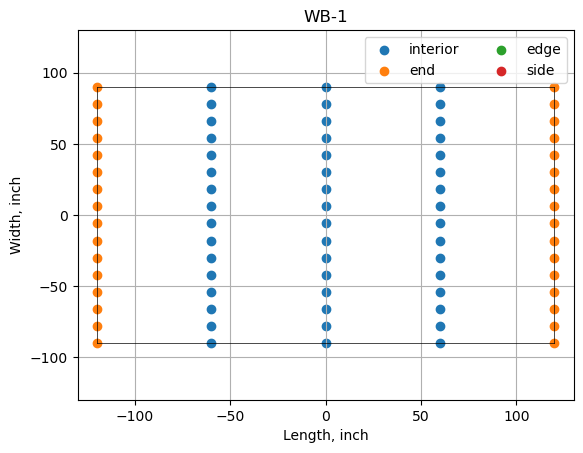

In [82]:
#WB1
interior_x, interior_y = support_group(3,16, (12*5), 12) #purlin
end_x, end_y = support_group(2,16,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-1')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [88]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+0
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.24 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/1.26))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.803))

Iter   0 | F = 5.837303e-01 | IC = (-0.00, -106.88)
Iter  10 | F = 4.768202e-01 | IC = (-0.00, -79.19)
Iter  20 | F = 4.867022e-01 | IC = (-0.00, -80.59)
Iter  30 | F = 4.866334e-01 | IC = (-0.00, -80.58)
Iter  40 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter  50 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter  60 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter  70 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter  80 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter  90 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 100 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 110 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 120 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 130 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 140 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 150 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 160 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 170 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 180 | F = 4.866339e-01 | IC = (-0.00, -80.58)
Iter 190 | F = 4.866339e-01 | 

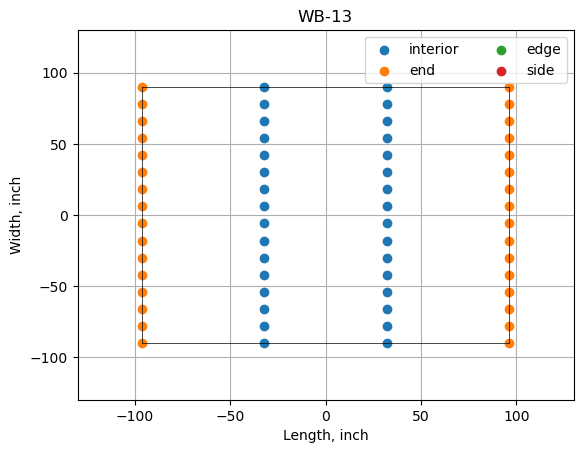

In [90]:
# WB 13 
interior_x, interior_y = support_group(2,16, (5*12)+4, 12) #purlin
end_x, end_y = support_group(2,16,12*16,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-13')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [98]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (5*12)+4
lamda = 1/(1+(Ls/135)**2)
L = 16 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.24 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/1.125))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.780))

Iter   0 | F = 5.982083e-01 | IC = (-0.00, -85.21)
Iter  10 | F = 2.928856e-01 | IC = (-0.00, -61.35)
Iter  20 | F = 2.768778e-01 | IC = (-0.00, -60.56)
Iter  30 | F = 2.710699e-01 | IC = (-0.00, -60.28)
Iter  40 | F = 2.686848e-01 | IC = (-0.00, -60.17)
Iter  50 | F = 2.677002e-01 | IC = (-0.00, -60.12)
Iter  60 | F = 2.672894e-01 | IC = (-0.00, -60.10)
Iter  70 | F = 2.671171e-01 | IC = (-0.00, -60.09)
Iter  80 | F = 2.670447e-01 | IC = (-0.00, -60.09)
Iter  90 | F = 2.670143e-01 | IC = (-0.00, -60.09)
Iter 100 | F = 2.670015e-01 | IC = (-0.00, -60.09)
Iter 110 | F = 2.669961e-01 | IC = (-0.00, -60.08)
Iter 120 | F = 2.669939e-01 | IC = (-0.00, -60.08)
Iter 130 | F = 2.669929e-01 | IC = (-0.00, -60.08)
Iter 140 | F = 2.669925e-01 | IC = (-0.00, -60.08)
Iter 150 | F = 2.669923e-01 | IC = (-0.00, -60.08)
Iter 160 | F = 2.669923e-01 | IC = (-0.00, -60.08)
Iter 170 | F = 2.669922e-01 | IC = (-0.00, -60.08)
Iter 180 | F = 2.669922e-01 | IC = (-0.00, -60.08)
Iter 190 | F = 2.669922e-01 | I

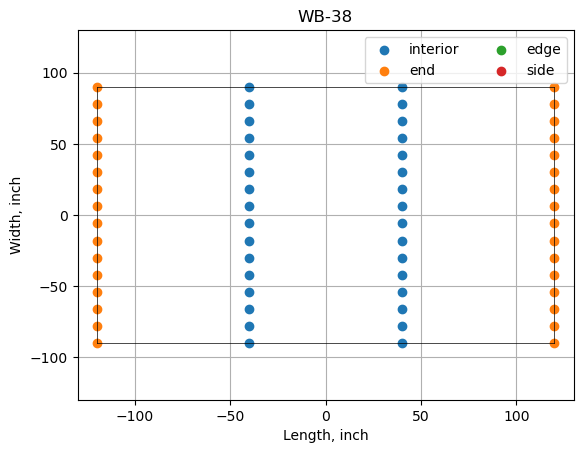

In [100]:
#WB38
interior_x, interior_y = support_group(2,16, (12*6)+8, 12) #purlin
end_x, end_y = support_group(2,16,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-38')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [106]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.24 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.460))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.599))

Iter   0 | F = 5.850341e-01 | IC = (-0.00, -115.21)
Iter  10 | F = 5.359851e-01 | IC = (-0.00, -88.56)
Iter  20 | F = 5.311956e-01 | IC = (-0.00, -87.74)
Iter  30 | F = 5.313559e-01 | IC = (-0.00, -87.77)
Iter  40 | F = 5.313508e-01 | IC = (-0.00, -87.77)
Iter  50 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter  60 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter  70 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter  80 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter  90 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 100 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 110 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 120 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 130 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 140 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 150 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 160 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 170 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 180 | F = 5.313510e-01 | IC = (-0.00, -87.77)
Iter 190 | F = 5.313510e-01 | 

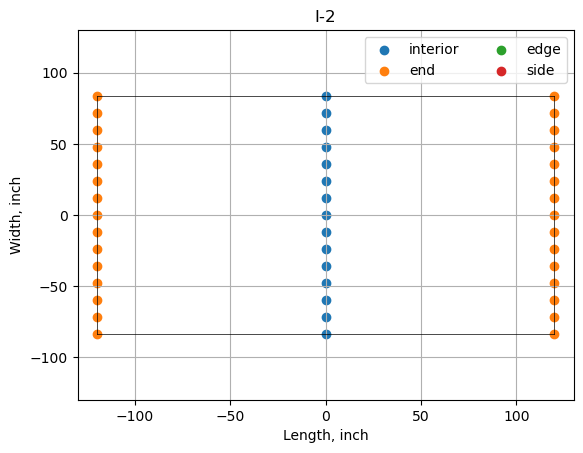

In [110]:
 #I-2
interior_x, interior_y = support_group(1,15,12*5, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]
plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('I-2')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [120]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (10*12)+0
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.24 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.550))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.413))

Iter   0 | F = 6.063765e-01 | IC = (-0.00, -128.00)
Iter  10 | F = 6.581281e-01 | IC = (-0.00, -15.94)
Iter  20 | F = 1.371057e-01 | IC = (-0.00, -45.65)
Iter  30 | F = 9.409509e-01 | IC = (-0.00, -2.93)
Iter  40 | F = 6.774786e-01 | IC = (-0.00, -15.05)
Iter  50 | F = 4.881218e-01 | IC = (-0.00, -22.96)
Iter  60 | F = 6.115732e-01 | IC = (-0.00, -124.43)
Iter  70 | F = 5.085056e-01 | IC = (-0.00, -70.31)
Iter  80 | F = 1.318938e-01 | IC = (-0.00, -45.40)
Iter  90 | F = 5.567341e-01 | IC = (-0.00, -20.09)
Iter 100 | F = 8.974841e-02 | IC = (-0.00, -43.45)
Iter 110 | F = 8.957805e-01 | IC = (-0.00, -5.31)
Iter 120 | F = 3.664918e-01 | IC = (-0.00, -26.53)
Iter 130 | F = 7.942201e-02 | IC = (-0.00, -36.35)
Iter 140 | F = 6.170344e-01 | IC = (-0.00, -119.93)
Iter 150 | F = 1.510537e-01 | IC = (-0.00, -46.32)
Iter 160 | F = 1.490223e-01 | IC = (-0.00, -46.22)
Iter 170 | F = 1.427071e-01 | IC = (-0.00, -45.92)
Iter 180 | F = 9.556657e-01 | IC = (-0.00, -2.03)
Iter 190 | F = 3.442197e-01 | I

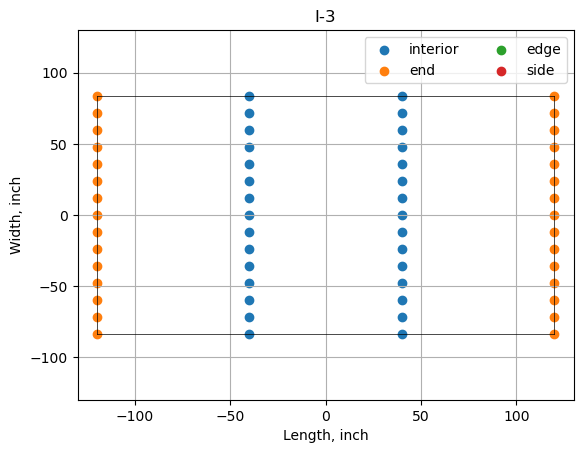

In [122]:
#I-3
interior_x, interior_y = support_group(2,15,6*12+8, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('I-3')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [130]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
L = 20 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.24 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types,3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.755))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.5))

Iter   0 | F = 6.054093e-01 | IC = (-0.00, -111.33)
Iter  10 | F = 5.820895e-01 | IC = (-0.00, -89.67)
Iter  20 | F = 5.538278e-01 | IC = (-0.00, -82.06)
Iter  30 | F = 5.811279e-01 | IC = (-0.00, -89.25)
Iter  40 | F = 5.548251e-01 | IC = (-0.00, -82.21)
Iter  50 | F = 5.810809e-01 | IC = (-0.00, -89.23)
Iter  60 | F = 5.548733e-01 | IC = (-0.00, -82.22)
Iter  70 | F = 5.810786e-01 | IC = (-0.00, -89.23)
Iter  80 | F = 5.548756e-01 | IC = (-0.00, -82.22)
Iter  90 | F = 5.810785e-01 | IC = (-0.00, -89.22)
Iter 100 | F = 5.548757e-01 | IC = (-0.00, -82.22)
Iter 110 | F = 5.810785e-01 | IC = (-0.00, -89.22)
Iter 120 | F = 5.548757e-01 | IC = (-0.00, -82.22)
Iter 130 | F = 5.810785e-01 | IC = (-0.00, -89.22)
Iter 140 | F = 5.548757e-01 | IC = (-0.00, -82.22)
Iter 150 | F = 5.810785e-01 | IC = (-0.00, -89.22)
Iter 160 | F = 5.548757e-01 | IC = (-0.00, -82.22)
Iter 170 | F = 5.810785e-01 | IC = (-0.00, -89.22)
Iter 180 | F = 5.548757e-01 | IC = (-0.00, -82.22)
Iter 190 | F = 5.810785e-01 | 